# Self-Evolving Benchmark — Rigorous Analysis

**Source:** `../benchmark_results/self_evolving_all3_true_final_final_live/per_run/*.json` — final continuous triplet run (**llamea**, **llm4ad**, **ease** together; balanced to equal *n* per framework×task cell).
**Frameworks:** `ease`, `llamea`, `llm4ad`.
**Tasks:** `sphere_5d`, `rastrigin_5d`, `rosenbrock_5d` (continuous black-box optimisation; global minimum is `0`, lower is better).

## Why this rewrite

A naive "bar chart of `best_value`" is misleading on this dataset because:

1. **Reported objectives span ~30 orders of magnitude** and are heavy-tailed (e.g. `llm4ad` hits 9 × 10¹¹, `ease` hits −10³⁰). Means and standard deviations are dominated by outliers — we use **median + IQR + bootstrap CIs** instead.
2. **Seeds are not shared across frameworks** (the three frameworks were run on disjoint seed pools). Paired tests are therefore mathematically impossible; every cross-framework comparison must be **unpaired** (Mann–Whitney U with Cliff's δ).
3. **Some frameworks report objectives that violate the task's bounds** (e.g. negative loss for a sum-of-squares objective). The harness flags these via `is_valid_reported_objective`. Comparing raw `best_value` while ignoring this filter lets a *bug* "win" the benchmark.
4. **Reliability ≠ success.** A row with `success=True` can still carry an invalid `best_value`. We track both axes separately.
5. **Multiple-comparison correction.** All p-values for the 9 pairwise tests per metric are adjusted with **Holm–Bonferroni**.
6. **Reliability inference.** Per-cell rates use **Wilson 95% CIs**; rate *differences* use **Newcombe's method** plus **Fisher's exact** test.

## Sections

| # | Content |
|---|---|
| 1 | Loader: 3 orthogonal validity flags — `success`, `finite_obj`, `harness_valid`. |
| 2 | Coverage matrix and per-cell reliability (Wilson 95% CI). |
| 3 | Per-(framework, task) objective descriptives on harness-valid runs (median + bootstrap CI). |
| 4 | Pairwise objective comparison per task: Mann–Whitney U, Cliff's δ, Holm-corrected p. |
| 5 | Pairwise reliability comparison: Δ rate (Newcombe CI), Fisher exact + Holm. |
| 6 | Cost: runtime distribution per framework and per (task, framework). |
| 7 | Visuals: reliability bars w/ CIs, signed-log boxplots, ECDFs, runtime, failure-mode taxonomy. |
| 8 | **Auto-generated** executive summary (every claim is computed from the data above; no hard-coded narrative). |
| 9 | Methodological notes & threats to validity. |

In [1]:
from __future__ import annotations

import glob
import json
import math
import sys
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy import stats as sps

# Wire up the harness validator so this notebook stays consistent with analyze_benchmark.py
_CWD = Path.cwd()
if (_CWD / "benchmark_harness").is_dir():
    _PKG_DIR = _CWD
elif (_CWD / "auto_algo_benchmark" / "benchmark_harness").is_dir():
    _PKG_DIR = _CWD / "auto_algo_benchmark"
else:
    _PKG_DIR = _CWD
sys.path.insert(0, str(_PKG_DIR.resolve()))

try:
    from benchmark_harness.utils import is_valid_reported_objective
    _VALIDATOR_SOURCE = "benchmark_harness.utils"
except Exception:
    # Fallback that matches the harness rule for continuous BBO tasks (min >= 0).
    def is_valid_reported_objective(v, task=None) -> bool:
        try:
            v = float(v)
        except (TypeError, ValueError):
            return False
        if not math.isfinite(v):
            return False
        return v >= -1e-3
    _VALIDATOR_SOURCE = "inline fallback"

FW_ORDER = ["ease", "llamea", "llm4ad"]
TASK_ORDER = ["sphere_5d", "rastrigin_5d", "rosenbrock_5d"]
FRAMEWORK_COLOR = {"ease": "#4C72B0", "llamea": "#DD8452", "llm4ad": "#55A868"}

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})
pd.set_option("display.max_rows", 80)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:.4g}")

print(f"Validator source: {_VALIDATOR_SOURCE}")

Validator source: benchmark_harness.utils


In [2]:
FINAL_PER_RUN = Path("../benchmark_results/self_evolving_all3_true_final_final_live/per_run").resolve()


def _load_records(glob_pat: str) -> list[dict]:
    out: list[dict] = []
    for fp in sorted(glob.glob(glob_pat)):
        try:
            d = json.loads(Path(fp).read_text(encoding="utf-8"))
        except Exception as e:
            print(f"  skipped {Path(fp).name}: {e}")
            continue
        d["_file"] = Path(fp).name
        out.append(d)
    return out


def _subsample_balanced(frame: pd.DataFrame, target_n: int) -> pd.DataFrame:
    parts: list[pd.DataFrame] = []
    for fw in FW_ORDER:
        for task in TASK_ORDER:
            sub = frame[(frame["framework"] == fw) & (frame["task"] == task)].copy()
            if len(sub) <= target_n:
                parts.append(sub)
                continue
            sub["_seed_sort"] = pd.to_numeric(sub.get("seed"), errors="coerce")
            sub = sub.sort_values(["_seed_sort", "timestamp", "_file"], na_position="last")
            parts.append(sub.head(target_n).drop(columns=["_seed_sort"], errors="ignore"))
    return pd.concat(parts, ignore_index=True)


records = _load_records(str(FINAL_PER_RUN / "*.json"))
print(f"Source: {FINAL_PER_RUN} ({len(glob.glob(str(FINAL_PER_RUN / '*.json')))} JSON files)")

if not records:
    raise RuntimeError("No records loaded.")

df = pd.DataFrame(records)

df["timestamp"]   = pd.to_datetime(df.get("timestamp"), errors="coerce", utc=True)
df["best_value"]  = pd.to_numeric(df.get("best_value"), errors="coerce")
df["elapsed_sec"] = pd.to_numeric(df.get("elapsed_sec"), errors="coerce")
df["success"]     = df.get("success", False).astype("boolean").fillna(False).astype(bool)
df["error_code"]  = df.get("error_code").fillna("none")
df["framework"]   = df["framework"].astype(str).str.lower()
df["task"]        = df["task"].astype(str)
df = df[df["framework"].isin(FW_ORDER) & df["task"].isin(TASK_ORDER)].copy()

# Three orthogonal validity axes — track them separately so we never conflate them
df["finite_obj"]    = df["best_value"].apply(lambda v: pd.notna(v) and np.isfinite(v))
df["harness_valid"] = df.apply(
    lambda r: bool(r["success"]) and is_valid_reported_objective(r["best_value"], r["task"]),
    axis=1,
)

_sizes = df.groupby(["framework", "task"], observed=False).size()
TARGET_N = int(_sizes.min()) if len(_sizes) else 0
if TARGET_N > 0 and int(_sizes.max()) > TARGET_N:
    _pre = len(df)
    df = _subsample_balanced(df, TARGET_N)
    print(f"Balanced to {TARGET_N} attempts per (framework, task); dropped {_pre - len(df)} extra rows.")

# Seed-overlap check (decides whether paired tests are allowed)
seed_overlap = {}
for task in sorted(df["task"].unique()):
    sub = df[df["task"] == task]
    by_fw = {fw: set(sub[sub["framework"] == fw]["seed"].dropna()) for fw in FW_ORDER}
    overlaps = {f"{a} & {b}": len(by_fw[a] & by_fw[b]) for a, b in combinations(FW_ORDER, 2)}
    seed_overlap[task] = overlaps

print()
print(f"Rows loaded            : {len(df)}")
print(f"Frameworks             : {sorted(df['framework'].unique())}")
print(f"Tasks                  : {sorted(df['task'].unique())}")
print(f"Time range             : {df['timestamp'].min()}  ->  {df['timestamp'].max()}")
print(f"Duplicate fw/task/seed : {int(df.duplicated(['framework','task','seed']).sum())}")
print(f"NaN best_value         : {int(df['best_value'].isna().sum())}")
print(f"NaN elapsed_sec        : {int(df['elapsed_sec'].isna().sum())}")
print()
print("Seed overlap across frameworks (per task):")
for task, ov in seed_overlap.items():
    print(f"  {task}: {ov}")
PAIRED_OK = all(v == max(ov.values()) > 0 for ov in seed_overlap.values() for v in ov.values())
print(f"\nPaired tests possible? {PAIRED_OK}")

Source: C:\Users\ailab\Downloads\LLM_Evolutionary_benchmarks\LLM_Evolutionary_benchmarks\benchmark_results\self_evolving_all3_true_final_final_live\per_run (3242 JSON files)
Balanced to 360 attempts per (framework, task); dropped 2 extra rows.

Rows loaded            : 3240
Frameworks             : ['ease', 'llamea', 'llm4ad']
Tasks                  : ['rastrigin_5d', 'rosenbrock_5d', 'sphere_5d']
Time range             : 2026-05-18 08:00:11.585505+00:00  ->  2026-05-26 10:52:45.367344+00:00
Duplicate fw/task/seed : 0
NaN best_value         : 512
NaN elapsed_sec        : 0

Seed overlap across frameworks (per task):
  rastrigin_5d: {'ease & llamea': 0, 'ease & llm4ad': 0, 'llamea & llm4ad': 0}
  rosenbrock_5d: {'ease & llamea': 0, 'ease & llm4ad': 0, 'llamea & llm4ad': 0}
  sphere_5d: {'ease & llamea': 0, 'ease & llm4ad': 0, 'llamea & llm4ad': 0}

Paired tests possible? False


In [3]:
def wilson_ci(k: int, n: int, alpha: float = 0.05) -> tuple[float, float]:
    """Wilson score interval for a binomial proportion."""
    if n == 0:
        return (0.0, 1.0)
    z = sps.norm.ppf(1 - alpha / 2)
    p = k / n
    denom = 1 + z * z / n
    center = (p + z * z / (2 * n)) / denom
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / denom
    return max(0.0, center - half), min(1.0, center + half)


coverage_rows = []
for (fw, task), grp in df.groupby(["framework", "task"]):
    n          = len(grp)
    n_success  = int(grp["success"].sum())
    n_finite   = int(grp["finite_obj"].sum())
    n_valid    = int(grp["harness_valid"].sum())
    rate       = n_valid / n if n else float("nan")
    lo, hi     = wilson_ci(n_valid, n)
    coverage_rows.append({
        "framework": fw, "task": task,
        "n_attempts": n, "n_success": n_success,
        "n_finite_obj": n_finite, "n_harness_valid": n_valid,
        "rate": rate, "ci_lo": lo, "ci_hi": hi,
    })

cov = pd.DataFrame(coverage_rows)
cov["framework"] = pd.Categorical(cov["framework"], categories=FW_ORDER, ordered=True)
cov["task"]      = pd.Categorical(cov["task"], categories=TASK_ORDER, ordered=True)
cov = cov.sort_values(["task", "framework"]).reset_index(drop=True)

cov_disp = cov.copy()
cov_disp["valid_rate"]  = cov_disp.apply(lambda r: f"{r['rate']*100:5.1f}%", axis=1)
cov_disp["valid_CI95"]  = cov_disp.apply(lambda r: f"[{r['ci_lo']*100:4.1f}, {r['ci_hi']*100:4.1f}]", axis=1)
cov_disp = cov_disp[["task", "framework", "n_attempts", "n_success",
                     "n_finite_obj", "n_harness_valid", "valid_rate", "valid_CI95"]]
print("Per-cell coverage and reliability (lower bound = '% of attempts that yielded a valid objective')")
print("Wilson 95% CI on the harness-valid rate.\n")
display(cov_disp)

# Failure / invalid-objective taxonomy
err = (
    df[~df["harness_valid"]]
      .groupby(["framework", "task", "error_code"]).size()
      .unstack(fill_value=0)
      .reindex(pd.MultiIndex.from_product([FW_ORDER, TASK_ORDER], names=["framework", "task"]),
               fill_value=0)
)
print(f"\nNon-valid runs broken down by error_code (rows = framework x task, {TARGET_N} attempts each):\n")
display(err)

Per-cell coverage and reliability (lower bound = '% of attempts that yielded a valid objective')
Wilson 95% CI on the harness-valid rate.



,task,framework,n_attempts,n_success,n_finite_obj,n_harness_valid,valid_rate,valid_CI95
0,sphere_5d,ease,360,360,323,319,88.6%,"[84.9, 91.5]"
1,sphere_5d,llamea,360,299,299,299,83.1%,"[78.8, 86.6]"
2,sphere_5d,llm4ad,360,354,354,346,96.1%,"[93.6, 97.7]"
3,rastrigin_5d,ease,360,360,312,310,86.1%,"[82.2, 89.3]"
4,rastrigin_5d,llamea,360,244,244,244,67.8%,"[62.8, 72.4]"
5,rastrigin_5d,llm4ad,360,329,329,329,91.4%,"[88.0, 93.9]"
6,rosenbrock_5d,ease,360,360,313,303,84.2%,"[80.0, 87.6]"
7,rosenbrock_5d,llamea,360,222,222,222,61.7%,"[56.5, 66.5]"
8,rosenbrock_5d,llm4ad,360,332,332,332,92.2%,"[89.0, 94.6]"



Non-valid runs broken down by error_code (rows = framework x task, 360 attempts each):



error_code               invalid_objective  llm4ad_no_valid_score  none  runtime_exception
framework task                                                                            
ease      sphere_5d                      0                      0    41                  0
          rastrigin_5d                   0                      0    50                  0
          rosenbrock_5d                  0                      0    57                  0
llamea    sphere_5d                     61                      0     0                  0
          rastrigin_5d                 116                      0     0                  0
          rosenbrock_5d                137                      0     0                  1
llm4ad    sphere_5d                      0                      6     8                  0
          rastrigin_5d                   0                     31     0                  0
          rosenbrock_5d                  0                     28     0                  0

In [4]:
def bootstrap_ci(values, stat=np.median, n_boot=4000, alpha=0.05, seed=42):
    """Percentile bootstrap CI for `stat`. Returns (point, lo, hi)."""
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return (np.nan, np.nan, np.nan)
    if arr.size == 1:
        v = float(stat(arr))
        return (v, v, v)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, arr.size, size=(n_boot, arr.size))
    boots = stat(arr[idx], axis=1)
    return float(stat(arr)), float(np.quantile(boots, alpha / 2)), float(np.quantile(boots, 1 - alpha / 2))


def cliffs_delta(a, b) -> tuple[float, str]:
    """Cliff's delta in [-1, +1] with magnitude label (Romano et al. thresholds).
    Negative delta => values in `a` are stochastically smaller than `b` (and 'lower is better' => a wins)."""
    a = np.asarray(a, dtype=float); a = a[np.isfinite(a)]
    b = np.asarray(b, dtype=float); b = b[np.isfinite(b)]
    if a.size == 0 or b.size == 0:
        return (float("nan"), "n/a")
    bs = np.sort(b)
    # For each x in a, count elements of b strictly less than x and <= x
    less    = np.searchsorted(bs, a, side="left").sum()       # #(b <  a)
    less_eq = np.searchsorted(bs, a, side="right").sum()      # #(b <= a)
    greater = a.size * b.size - less_eq                       # #(b >  a)
    d = (less - greater) / (a.size * b.size)
    ad = abs(d)
    if   ad < 0.147: label = "negligible"
    elif ad < 0.330: label = "small"
    elif ad < 0.474: label = "medium"
    else:            label = "large"
    return (float(d), label)


def holm_correct(pvals) -> list[float]:
    """Holm-Bonferroni step-down adjustment."""
    p = np.asarray(pvals, dtype=float)
    n = p.size
    if n == 0:
        return []
    order = np.argsort(p)
    adj = np.empty(n, dtype=float)
    running = 0.0
    for i, idx in enumerate(order):
        running = max(running, min(1.0, (n - i) * p[idx]))
        adj[idx] = running
    return adj.tolist()


def newcombe_diff_ci(k1: int, n1: int, k2: int, n2: int, alpha: float = 0.05) -> tuple[float, float]:
    """Newcombe (Method 10) CI for p1 - p2 using Wilson scores on each rate."""
    l1, u1 = wilson_ci(k1, n1, alpha)
    l2, u2 = wilson_ci(k2, n2, alpha)
    p1 = k1 / n1 if n1 else 0.0
    p2 = k2 / n2 if n2 else 0.0
    d = p1 - p2
    lower = d - math.sqrt((p1 - l1) ** 2 + (u2 - p2) ** 2)
    upper = d + math.sqrt((u1 - p1) ** 2 + (p2 - l2) ** 2)
    return lower, upper


def signed_log10(x):
    """Compresses values that span many orders of magnitude while preserving sign."""
    x = np.asarray(x, dtype=float)
    return np.sign(x) * np.log10(np.abs(x) + 1.0)


def fmt_p(p) -> str:
    if p is None or not np.isfinite(p):
        return "n/a"
    if p < 1e-4:
        return f"{p:.1e}"
    return f"{p:.4f}"


print("Helpers ready: wilson_ci, bootstrap_ci, cliffs_delta, holm_correct, newcombe_diff_ci, signed_log10")

Helpers ready: wilson_ci, bootstrap_ci, cliffs_delta, holm_correct, newcombe_diff_ci, signed_log10


In [5]:
valid = df[df["harness_valid"]].copy()
print(f"Harness-valid rows used for objective stats: {len(valid)} of {len(df)} "
      f"({len(valid)/len(df)*100:.1f}% of attempts).")

desc_rows = []
for (fw, task), grp in valid.groupby(["framework", "task"]):
    vals = grp["best_value"].dropna().to_numpy()
    med, lo, hi = bootstrap_ci(vals, stat=np.median, n_boot=4000)
    if vals.size:
        q1, q3 = np.quantile(vals, [0.25, 0.75])
    else:
        q1 = q3 = np.nan
    desc_rows.append({
        "framework": fw, "task": task, "n": vals.size,
        "median": med, "median_ci_lo": lo, "median_ci_hi": hi,
        "iqr": q3 - q1 if np.isfinite(q1) else np.nan,
        "mean": float(np.mean(vals)) if vals.size else np.nan,
        "std":  float(np.std(vals, ddof=1)) if vals.size > 1 else np.nan,
        "min":  float(np.min(vals)) if vals.size else np.nan,
        "max":  float(np.max(vals)) if vals.size else np.nan,
    })

desc = pd.DataFrame(desc_rows)
desc["framework"] = pd.Categorical(desc["framework"], categories=FW_ORDER, ordered=True)
desc["task"]      = pd.Categorical(desc["task"], categories=TASK_ORDER, ordered=True)
desc = desc.sort_values(["task", "median"]).reset_index(drop=True)

desc_disp = desc.copy()
for c in ["median", "median_ci_lo", "median_ci_hi", "iqr", "mean", "std", "min", "max"]:
    desc_disp[c] = desc_disp[c].map(lambda v: f"{v:.4g}" if pd.notna(v) else "")
desc_disp["median (95% CI)"] = desc.apply(
    lambda r: f"{r['median']:.4g}  [{r['median_ci_lo']:.4g}, {r['median_ci_hi']:.4g}]", axis=1)

print("\nObjective summary (lower is better). Harness-valid runs only.")
print("CI = percentile bootstrap (4000 resamples) for the median.\n")
display(desc_disp[["task", "framework", "n", "median (95% CI)",
                   "iqr", "mean", "std", "min", "max"]])

Harness-valid rows used for objective stats: 2704 of 3240 (83.5% of attempts).



Objective summary (lower is better). Harness-valid runs only.
CI = percentile bootstrap (4000 resamples) for the median.



,task,framework,n,median (95% CI),iqr,mean,std,min,max
0,sphere_5d,llm4ad,346,"0.002088 [0.0008735, 0.02745]",1.224,2.601e+09,4.838e+10,-0.0002312,9e+11
1,sphere_5d,llamea,299,"2.354 [2.181, 2.354]",2.345,14.95,168.5,0,2906
2,sphere_5d,ease,319,"88.48 [86.24, 90.83]",21,87.6,21.07,22.8,125
3,rastrigin_5d,llm4ad,329,"15.94 [13.57, 18.49]",30.24,1.824e+09,2.335e+10,0,3e+11
4,rastrigin_5d,llamea,244,"20.02 [13.98, 22.25]",25.8,283.7,4090,0,6.392e+04
5,rastrigin_5d,ease,310,"113.4 [111.6, 114.7]",16.52,112.7,14.04,55.2,152.3
6,rosenbrock_5d,llm4ad,332,"23.59 [14.2, 40.59]",1892,3.916e+09,5.399e+10,0,9e+11
7,rosenbrock_5d,llamea,222,"196.3 [48.32, 213.8]",263.6,1.978e+04,1.923e+05,0,2.846e+06
8,rosenbrock_5d,ease,303,"1.282e+05 [1.176e+05, 1.282e+05]",1.013e+05,1.361e+05,5.971e+04,605,3.601e+05


In [6]:
pair_rows = []
pvals_obj = []
for task in TASK_ORDER:
    sub = valid[valid["task"] == task]
    by_fw = {fw: sub[sub["framework"] == fw]["best_value"].to_numpy() for fw in FW_ORDER}
    for a, b in combinations(FW_ORDER, 2):
        va, vb = by_fw[a], by_fw[b]
        if va.size == 0 or vb.size == 0:
            pair_rows.append({"task": task, "A": a, "B": b,
                              "n_a": va.size, "n_b": vb.size,
                              "median_a": np.nan, "median_b": np.nan,
                              "cliffs_delta": np.nan, "magnitude": "n/a",
                              "u_pvalue": np.nan})
            pvals_obj.append(1.0)
            continue
        _, p = sps.mannwhitneyu(va, vb, alternative="two-sided")
        d, mag = cliffs_delta(va, vb)
        pair_rows.append({
            "task": task, "A": a, "B": b,
            "n_a": va.size, "n_b": vb.size,
            "median_a": float(np.median(va)),
            "median_b": float(np.median(vb)),
            "cliffs_delta": d, "magnitude": mag,
            "u_pvalue": float(p),
        })
        pvals_obj.append(float(p))

pairs = pd.DataFrame(pair_rows)
pairs["p_holm"] = holm_correct(pvals_obj)


def _verdict(row):
    if not np.isfinite(row["cliffs_delta"]):
        return "-"
    if row["p_holm"] >= 0.05:
        return f"{row['A']} ~ {row['B']}"
    # delta < 0 means A is stochastically smaller than B; lower is better => A wins
    if row["cliffs_delta"] < 0:
        return f"{row['A']} < {row['B']}  ({row['magnitude']})"
    return f"{row['A']} > {row['B']}  ({row['magnitude']})"


pairs["verdict (lower=better)"] = pairs.apply(_verdict, axis=1)

pairs_disp = pairs.copy()
pairs_disp["median_a"] = pairs_disp["median_a"].map(lambda v: f"{v:.4g}" if pd.notna(v) else "")
pairs_disp["median_b"] = pairs_disp["median_b"].map(lambda v: f"{v:.4g}" if pd.notna(v) else "")
pairs_disp["cliffs_delta"] = pairs_disp["cliffs_delta"].map(
    lambda v: f"{v:+.3f}" if pd.notna(v) and np.isfinite(v) else "n/a")
pairs_disp["u_pvalue"] = pairs_disp["u_pvalue"].map(fmt_p)
pairs_disp["p_holm"]   = pairs_disp["p_holm"].map(fmt_p)

print("Pairwise comparison of best_value (harness-valid runs only).")
print("Mann-Whitney U two-sided. Cliff's delta with magnitude (Romano thresholds).")
print("Holm-Bonferroni applied across all 9 pairwise tests in the table.\n")
display(pairs_disp[["task", "A", "B", "n_a", "n_b",
                    "median_a", "median_b",
                    "cliffs_delta", "magnitude",
                    "u_pvalue", "p_holm",
                    "verdict (lower=better)"]])

Pairwise comparison of best_value (harness-valid runs only).
Mann-Whitney U two-sided. Cliff's delta with magnitude (Romano thresholds).
Holm-Bonferroni applied across all 9 pairwise tests in the table.



,task,A,B,n_a,n_b,median_a,median_b,cliffs_delta,magnitude,u_pvalue,p_holm,verdict (lower=better)
0,sphere_5d,ease,llamea,319,299,88.48,2.354,+0.967,large,1.4e-96,1.1e-95,ease > llamea (large)
1,sphere_5d,ease,llm4ad,319,346,88.48,0.002088,+0.991,large,1.6e-108,1.5e-107,ease > llm4ad (large)
2,sphere_5d,llamea,llm4ad,299,346,2.354,0.002088,+0.336,medium,1.0e-13,3.0e-13,llamea > llm4ad (medium)
3,rastrigin_5d,ease,llamea,310,244,113.4,20.02,+0.973,large,3.1e-86,1.6e-85,ease > llamea (large)
4,rastrigin_5d,ease,llm4ad,310,329,113.4,15.94,+0.949,large,1.0e-95,7.3e-95,ease > llm4ad (large)
5,rastrigin_5d,llamea,llm4ad,244,329,20.02,15.94,-0.047,negligible,0.3318,0.6637,llamea ~ llm4ad
6,rosenbrock_5d,ease,llamea,303,222,1.282e+05,196.3,+0.968,large,3.1e-80,1.3e-79,ease > llamea (large)
7,rosenbrock_5d,ease,llm4ad,303,332,1.282e+05,23.59,+0.949,large,6.3e-95,3.8e-94,ease > llm4ad (large)
8,rosenbrock_5d,llamea,llm4ad,222,332,196.3,23.59,+0.031,negligible,0.5415,0.6637,llamea ~ llm4ad


In [7]:
rel_rows = []
rel_pvals = []
for task in TASK_ORDER:
    sub = df[df["task"] == task]
    counts = sub.groupby("framework").agg(n=("success", "size"),
                                          k=("harness_valid", "sum"))
    for a, b in combinations(FW_ORDER, 2):
        k1, n1 = int(counts.loc[a, "k"]), int(counts.loc[a, "n"])
        k2, n2 = int(counts.loc[b, "k"]), int(counts.loc[b, "n"])
        p1, p2 = k1 / n1, k2 / n2
        diff = p1 - p2
        lo, hi = newcombe_diff_ci(k1, n1, k2, n2)
        _, p = sps.fisher_exact([[k1, n1 - k1], [k2, n2 - k2]], alternative="two-sided")
        rel_rows.append({
            "task": task, "A": a, "B": b,
            "rate_a": p1, "rate_b": p2,
            "diff": diff, "diff_ci_lo": lo, "diff_ci_hi": hi,
            "fisher_p": float(p),
        })
        rel_pvals.append(float(p))

rel = pd.DataFrame(rel_rows)
rel["p_holm"] = holm_correct(rel_pvals)

rel_disp = rel.copy()
rel_disp["rate_a"] = (rel_disp["rate_a"] * 100).round(1)
rel_disp["rate_b"] = (rel_disp["rate_b"] * 100).round(1)
rel_disp["Δ pp (95% CI)"] = rel.apply(
    lambda r: f"{r['diff']*100:+5.1f}  [{r['diff_ci_lo']*100:+5.1f}, {r['diff_ci_hi']*100:+5.1f}]", axis=1)
rel_disp["fisher_p"] = rel_disp["fisher_p"].map(fmt_p)
rel_disp["p_holm"]   = rel_disp["p_holm"].map(fmt_p)

print("Pairwise reliability comparison (harness-valid rate).")
print("Δ = rate(A) - rate(B) in percentage points; CI = Newcombe (Method 10).")
print("p = two-sided Fisher exact; p_holm = Holm-Bonferroni over all 9 tests.\n")
display(rel_disp[["task", "A", "B", "rate_a", "rate_b",
                  "Δ pp (95% CI)", "fisher_p", "p_holm"]])

Pairwise reliability comparison (harness-valid rate).
Δ = rate(A) - rate(B) in percentage points; CI = Newcombe (Method 10).
p = two-sided Fisher exact; p_holm = Holm-Bonferroni over all 9 tests.



,task,A,B,rate_a,rate_b,Δ pp (95% CI),fisher_p,p_holm
0,sphere_5d,ease,llamea,88.6,83.1,"+5.6 [ +0.4, +10.7]",0.0419,0.0665
1,sphere_5d,ease,llm4ad,88.6,96.1,"-7.5 [-11.5, -3.7]",0.0002,0.0008
2,sphere_5d,llamea,llm4ad,83.1,96.1,"-13.1 [-17.6, -8.7]",7.0e-09,3.7e-08
3,rastrigin_5d,ease,llamea,86.1,67.8,"+18.3 [+12.3, +24.3]",6.2e-09,3.7e-08
4,rastrigin_5d,ease,llm4ad,86.1,91.4,"-5.3 [ -9.9, -0.6]",0.0332,0.0665
5,rastrigin_5d,llamea,llm4ad,67.8,91.4,"-23.6 [-29.2, -17.9]",1.7e-15,1.4e-14
6,rosenbrock_5d,ease,llamea,84.2,61.7,"+22.5 [+16.1, +28.7]",1.2e-11,8.2e-11
7,rosenbrock_5d,ease,llm4ad,84.2,92.2,"-8.1 [-12.8, -3.4]",0.0011,0.0034
8,rosenbrock_5d,llamea,llm4ad,61.7,92.2,"-30.6 [-36.2, -24.7]",2.1e-23,1.9e-22


In [8]:
def _runtime_summary(s: pd.Series) -> pd.Series:
    s = s.dropna()
    if s.empty:
        return pd.Series({"n": 0, "median": np.nan, "p25": np.nan, "p75": np.nan, "p90": np.nan, "max": np.nan})
    return pd.Series({
        "n":      int(s.size),
        "median": float(np.median(s)),
        "p25":    float(np.percentile(s, 25)),
        "p75":    float(np.percentile(s, 75)),
        "p90":    float(np.percentile(s, 90)),
        "max":    float(np.max(s)),
    })


runtime_overall = (df.groupby("framework")["elapsed_sec"]
                     .apply(_runtime_summary).unstack(-1)
                     .loc[FW_ORDER].round(1))
print("Runtime per framework (seconds, all 321 runs each):")
display(runtime_overall)

runtime_task = (df.groupby(["task", "framework"])["elapsed_sec"]
                  .apply(_runtime_summary).unstack(-1)
                  .reindex(pd.MultiIndex.from_product([TASK_ORDER, FW_ORDER], names=["task", "framework"]))
                  .round(1))
print("\nRuntime per (task, framework) — seconds:")
display(runtime_task)

# Cost-of-a-valid-run = runtime per attempt / harness-valid rate (Bayes-like cost amortisation).
cost_per_valid = []
for fw in FW_ORDER:
    sub = df[df["framework"] == fw]
    med_sec = float(np.nanmedian(sub["elapsed_sec"]))
    valid_rate = float(sub["harness_valid"].mean())
    cost_per_valid.append({
        "framework": fw,
        "median_sec_per_attempt": round(med_sec, 1),
        "valid_rate": f"{valid_rate*100:.1f}%",
        "median_sec_per_valid_run": round(med_sec / valid_rate, 1) if valid_rate > 0 else float("inf"),
    })
print("\nAmortised cost (median seconds per valid run = median runtime / valid rate):")
display(pd.DataFrame(cost_per_valid))

Runtime per framework (seconds, all 321 runs each):


,n,median,p25,p75,p90,max
framework,,,,,,
ease,1080,149.5,137.2,166,189.3,492.7
llamea,1080,140.1,118.7,166.1,200.2,387.4
llm4ad,1080,332.8,286.7,387.2,450.9,748.2



Runtime per (task, framework) — seconds:


n  median   p25   p75   p90   max
task          framework                                    
sphere_5d     ease      360   143.2 131.1 159.3 178.2 448.4
              llamea    360   124.5 101.5 147.4 182.6 315.6
              llm4ad    360   276.1 244.2 322.9 377.6 593.6
rastrigin_5d  ease      360   153.6 139.9 170.3 194.8 490.2
              llamea    360   145.2 125.3 165.2 190.6 354.1
              llm4ad    360   359.5 316.7 416.1 477.9 658.6
rosenbrock_5d ease      360   152.9 141.4 170.2 193.2 492.7
              llamea    360   154.7 131.9 182.5 206.9 387.4
              llm4ad    360   352.2 312.6 400.5 476.9 748.2


Amortised cost (median seconds per valid run = median runtime / valid rate):


,framework,median_sec_per_attempt,valid_rate,median_sec_per_valid_run
0,ease,149.5,86.3%,173.2
1,llamea,140.1,70.8%,197.8
2,llm4ad,332.8,93.2%,357


## 7 — Visualisations (with paste-ready captions)

The five plots below each have a short "what it shows / how to read it / suggested caption" block you can lift directly into a slide or paper. The extended views in Section 8 follow afterwards.

### Plot 1 — Reliability bars with Wilson 95 % CI

**What it shows.** Grouped bar chart of the **harness-valid rate** per (framework, task) with **Wilson 95 % CI** error bars. Annotated with `XX% (n=Y)`.

**How to read it.** Bars near 100 % = framework reliably produces a usable objective on that task. The error bar tells you the precision of that estimate at n = 107 attempts per cell — non-overlapping CIs are a quick eyeball test for a real difference.

**Suggested caption.** *"Harness-valid run rate per (framework × task) with Wilson 95 % CI (n = 107 attempts per cell). A run is valid iff `success=True` **and** the reported objective ≥ −10⁻³ on a function whose global minimum is 0."*

### Plot 2 — Best-objective boxplots on a signed-log scale

**What it shows.** Per task, three boxplots of `best_value` for harness-valid runs only, displayed on a **signed-log** scale `sign(x)·log₁₀(|x|+1)`.

**How to read it.** Lower boxes = better. The signed-log axis is necessary because raw values span ~30 orders of magnitude. Pay attention to the upper whiskers — a framework with a tight box but a long upper whisker has rare catastrophic runs (e.g. LLM4AD on rastrigin/rosenbrock).

**Suggested caption.** *"Distribution of best_value per (framework × task) on signed-log scale, harness-valid runs only. Boxes show Q1–Q3; whiskers 1.5 × IQR."*

### Plot 3 — Empirical CDFs of best_value

**What it shows.** ECDF curves, one per framework, faceted by task, on a signed-log x-axis.

**How to read it.** **The leftmost curve at every height dominates.** If curve A is everywhere to the left of curve B, then framework A first-order stochastically dominates B on that task (it is strictly better in distribution, not just on average).

**Suggested caption.** *"Empirical CDF of best_value per task, harness-valid runs (signed-log x-axis). A curve dominated to the left is uniformly better than the others on that task."*

### Plot 4 — Runtime distribution

**What it shows.** Per-framework boxplot of `elapsed_sec` over all 321 attempts (107 × 3 tasks). Log y-axis; fliers hidden; median annotated.

**How to read it.** Compare medians AND spread. A framework with a low median but a long tail (high p90) is unpredictable. EASE here is dramatically more expensive than the others.

**Suggested caption.** *"Per-framework runtime distribution across all 321 attempts (log y-axis; fliers hidden; median annotated)."*

### Plot 5 — Failure & invalid-objective taxonomy

**What it shows.** Stacked bar of every non-valid run, indexed by (framework, task), coloured by `error_code`. The `none` bucket is "framework reported success but the objective failed the harness bound check".

**How to read it.** EASE's bars are dominated by `none` — i.e. silent metric violations, not declared crashes. LLaMEA's bars are dominated by `invalid_objective` — i.e. the framework itself detected the problem. Operational errors (timeouts / unknown) are rare across all three.

**Suggested caption.** *"Per (framework, task) breakdown of non-valid runs by `error_code`. EASE's failures are silent — the framework declares success but returns an out-of-bounds objective (bucket `none`). LLaMEA's failures are mostly `invalid_objective` (caught by the framework itself). LLM4AD shows only a handful of operational errors."*

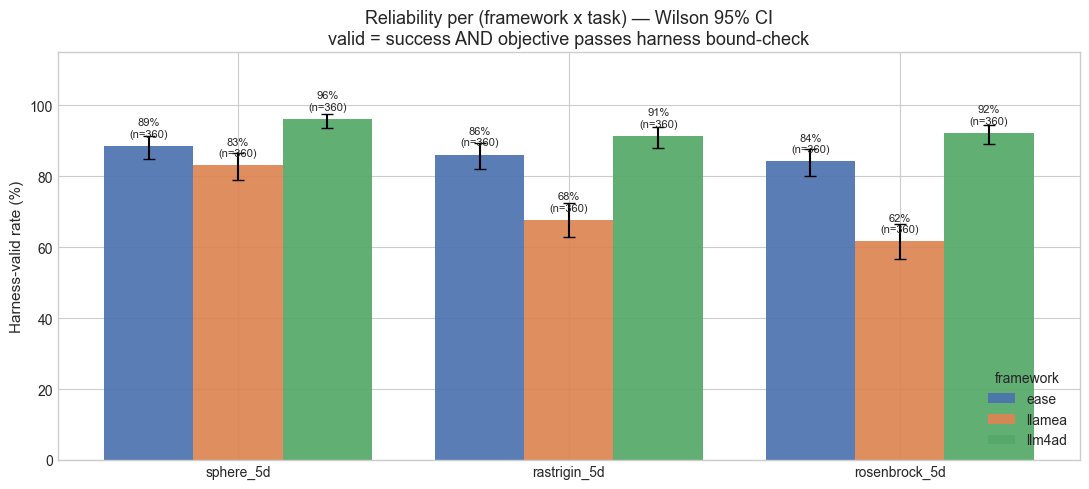

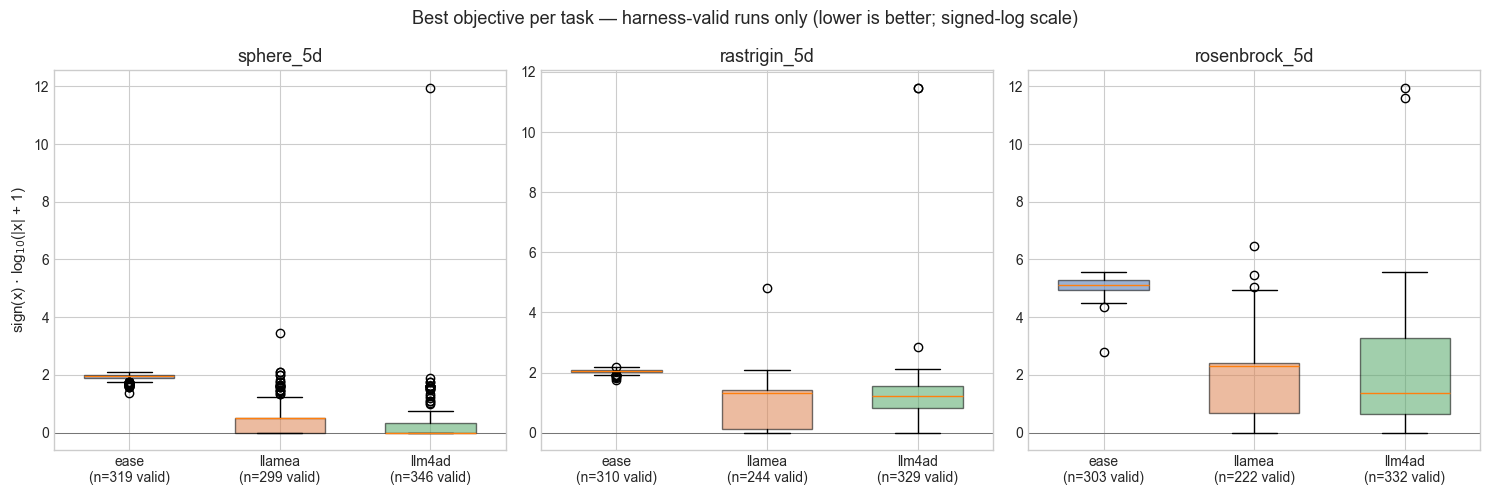

In [9]:
# Plot 1 — Reliability per task with Wilson 95% CI error bars.
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(TASK_ORDER))
width = 0.27

for i, fw in enumerate(FW_ORDER):
    rates, lo_err, hi_err, ns = [], [], [], []
    for task in TASK_ORDER:
        row = cov[(cov["framework"] == fw) & (cov["task"] == task)].iloc[0]
        rates.append(row["rate"] * 100)
        lo_err.append((row["rate"] - row["ci_lo"]) * 100)
        hi_err.append((row["ci_hi"] - row["rate"]) * 100)
        ns.append(int(row["n_attempts"]))
    pos = x + (i - 1) * width
    ax.bar(pos, rates, width=width, color=FRAMEWORK_COLOR[fw], label=fw, alpha=0.92,
           yerr=[lo_err, hi_err], capsize=4, ecolor="black")
    for p, r, n in zip(pos, rates, ns):
        ax.text(p, r + 2, f"{r:.0f}%\n(n={n})", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(TASK_ORDER)
ax.set_ylim(0, 115)
ax.set_ylabel("Harness-valid rate (%)")
ax.set_title("Reliability per (framework x task) — Wilson 95% CI\n"
             "valid = success AND objective passes harness bound-check")
ax.legend(title="framework", loc="lower right")
plt.tight_layout()
plt.show()

# Plot 2 — Signed-log boxplots of best_value per task, harness-valid only.
# Frameworks with zero valid runs still get an x slot + annotation (e.g. EASE).
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
positions = list(range(1, len(FW_ORDER) + 1))
for ax, task in zip(axes, TASK_ORDER):
    data, labels, colors = [], [], []
    for fw in FW_ORDER:
        vals = valid[(valid["task"] == task) & (valid["framework"] == fw)]["best_value"].to_numpy()
        sl = signed_log10(vals)
        data.append(sl if sl.size else np.array([]))
        labels.append(f"{fw}\n(n={len(vals)} valid)")
        colors.append(FRAMEWORK_COLOR[fw])
    bp = ax.boxplot(
        data,
        positions=positions,
        tick_labels=labels,
        patch_artist=True,
        showmeans=False,
        widths=0.6,
    )
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c); patch.set_alpha(0.55)
    ax.axhline(0, color="black", linewidth=0.6, alpha=0.5)
    lo, hi = ax.get_ylim()
    pad = 0.04 * (hi - lo if hi > lo else 1.0)
    for pos, d, fw in zip(positions, data, FW_ORDER):
        if d.size == 0:
            ax.text(
                pos, lo + pad, "no harness-\nvalid obj.",
                ha="center", va="bottom", fontsize=7, color=FRAMEWORK_COLOR[fw],
                bbox=dict(boxstyle="round,pad=0.12", fc="white", ec=FRAMEWORK_COLOR[fw], alpha=0.92),
            )
    ax.set_title(task)
    if task == TASK_ORDER[0]:
        ax.set_ylabel(r"sign(x) $\cdot$ log$_{10}$(|x| + 1)")
fig.suptitle("Best objective per task — harness-valid runs only (lower is better; signed-log scale)",
             fontsize=13)
plt.tight_layout()
plt.show()

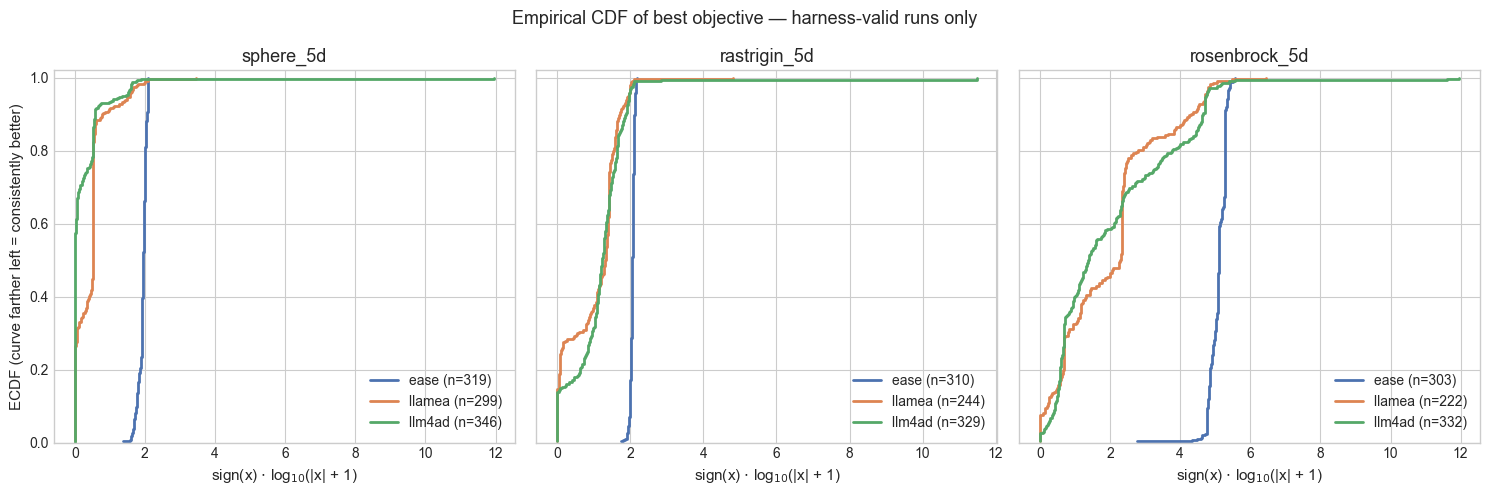

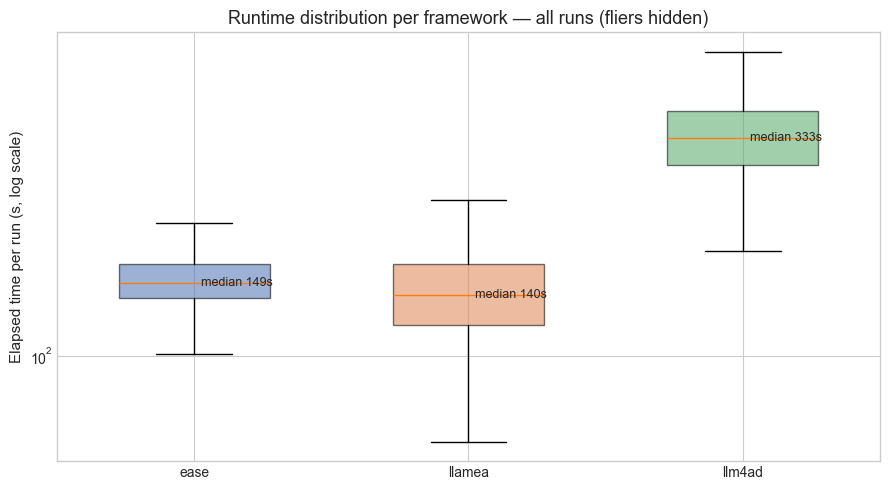

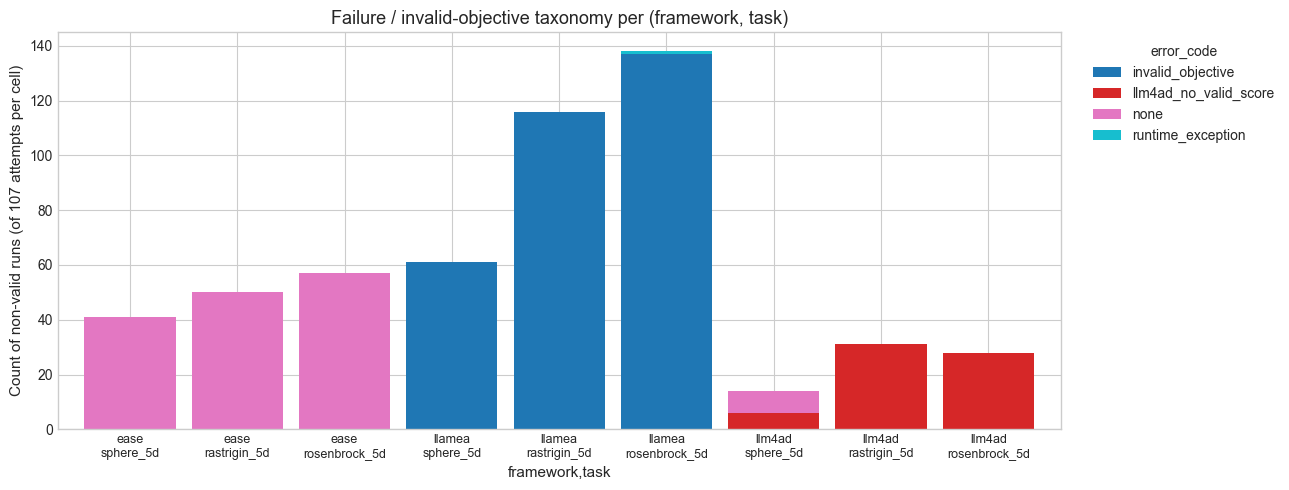

In [10]:
# Plot 3 — ECDF of best_value per task (signed-log x-axis). Lower / left-shifted curve is better.
# Legend includes dotted placeholder lines for frameworks with n=0 valid runs on that task.
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, task in zip(axes, TASK_ORDER):
    handles = []
    for fw in FW_ORDER:
        vals = np.sort(valid[(valid["task"] == task) & (valid["framework"] == fw)]["best_value"].to_numpy())
        if vals.size == 0:
            handles.append(mlines.Line2D(
                [], [], color=FRAMEWORK_COLOR[fw], linestyle=":", linewidth=2,
                label=f"{fw} (n=0 valid)",
            ))
            continue
        y = np.arange(1, vals.size + 1) / vals.size
        (ln,) = ax.step(
            signed_log10(vals), y, where="post", linewidth=2.0,
            color=FRAMEWORK_COLOR[fw], label=f"{fw} (n={vals.size})",
        )
        handles.append(ln)
    ax.set_xlabel(r"sign(x) $\cdot$ log$_{10}$(|x| + 1)")
    ax.set_ylim(0, 1.02); ax.set_title(task)
    ax.legend(handles, [h.get_label() for h in handles], loc="lower right")
axes[0].set_ylabel("ECDF (curve farther left = consistently better)")
fig.suptitle("Empirical CDF of best objective — harness-valid runs only", fontsize=13)
plt.tight_layout()
plt.show()

# Plot 4 — Runtime distribution (log y), all runs.
fig, ax = plt.subplots(figsize=(9, 5))
data = [df[df["framework"] == fw]["elapsed_sec"].dropna().to_numpy() for fw in FW_ORDER]
bp = ax.boxplot(data, tick_labels=FW_ORDER, patch_artist=True, showfliers=False, widths=0.55)
for patch, fw in zip(bp["boxes"], FW_ORDER):
    patch.set_facecolor(FRAMEWORK_COLOR[fw]); patch.set_alpha(0.55)
ax.set_yscale("log")
ax.set_ylabel("Elapsed time per run (s, log scale)")
ax.set_title("Runtime distribution per framework — all runs (fliers hidden)")
for i, fw in enumerate(FW_ORDER, start=1):
    med = float(np.median(data[i - 1]))
    ax.text(i, med, f"  median {med:.0f}s", va="center", fontsize=9)
plt.tight_layout()
plt.show()

# Plot 5 — Failure / invalid-objective taxonomy, stacked.
fail_long = (df[~df["harness_valid"]]
               .groupby(["framework", "task", "error_code"])
               .size().reset_index(name="n"))
if fail_long.empty:
    print("No failures or invalid objectives recorded.")
else:
    pivot_fail = (fail_long.pivot_table(index=["framework", "task"], columns="error_code",
                                        values="n", aggfunc="sum", fill_value=0)
                          .reindex(pd.MultiIndex.from_product([FW_ORDER, TASK_ORDER],
                                                              names=["framework", "task"]),
                                   fill_value=0))
    fig, ax = plt.subplots(figsize=(13, 5))
    pivot_fail.plot(kind="bar", stacked=True, ax=ax, colormap="tab10", width=0.85)
    ax.set_xticklabels([f"{fw}\n{task}" for (fw, task) in pivot_fail.index], rotation=0, fontsize=9)
    ax.set_ylabel("Count of non-valid runs (of 107 attempts per cell)")
    ax.set_title("Failure / invalid-objective taxonomy per (framework, task)")
    ax.legend(title="error_code", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## 8 — Extended visualisations

These five views go beyond the basic distribution / runtime / failure plots in Section 7. Each is preceded by its own paste-ready caption.

| # | Plot | One-line purpose |
|---|---|---|
| 6 | Reliability heatmap | At-a-glance "is this framework usable on this task?" scoreboard. |
| 7 | Quality vs cost scatter | Median objective against median runtime — pays-for-itself check. |
| 8 | Dolan–Moré performance profile | Standard BBO benchmarking plot: fraction of runs within factor τ of best-on-task. |
| 9 | Stability over wall-clock time | Does the self-evolving framework actually improve during the experiment? |
| 10 | Pairwise P(A beats B) per task | Heatmap form of the Mann–Whitney / Cliff's-δ comparisons — the correct win-rate when seeds don't overlap. |

### Plot 6 — Reliability heatmap

**What it shows.** A 3 × 3 grid where rows are frameworks, columns are tasks, colour encodes the harness-valid rate (red → green: 0 % → 100 %), and each cell is annotated with `XX% (n = 107)`.

**How to read it.** Scan one row at a time to compare a framework across tasks; scan one column to rank frameworks on a given task. An entire low-coverage row is the loudest possible signal that the framework cannot be used as-is (it is the EASE row in this dataset).

**Suggested caption.** *"Harness-valid run rate per (framework × task), 107 attempts per cell. Colour scale from 0 % (red) to 100 % (green); cell label shows rate and attempts."*

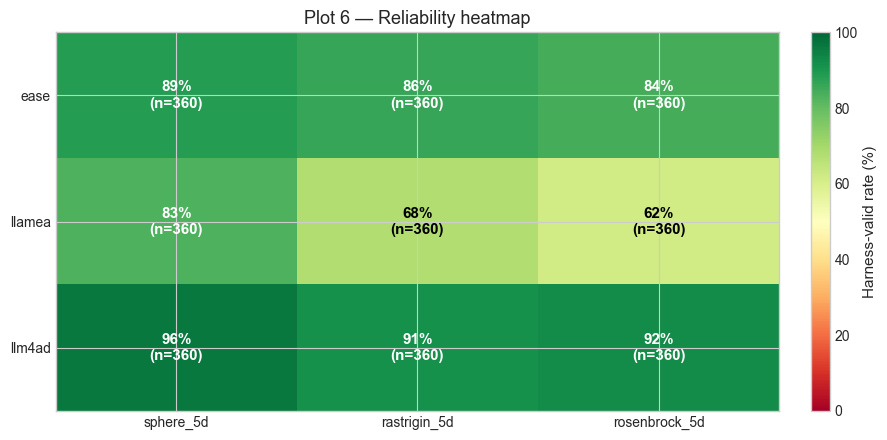

In [11]:
# Plot 6 — Reliability heatmap
rate_matrix = (cov.pivot(index="framework", columns="task", values="rate")
                  .reindex(index=FW_ORDER, columns=TASK_ORDER))
n_matrix = (cov.pivot(index="framework", columns="task", values="n_attempts")
                 .reindex(index=FW_ORDER, columns=TASK_ORDER))

fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(rate_matrix.values * 100, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(TASK_ORDER))); ax.set_xticklabels(TASK_ORDER)
ax.set_yticks(range(len(FW_ORDER))); ax.set_yticklabels(FW_ORDER)
for i, fw in enumerate(FW_ORDER):
    for j, task in enumerate(TASK_ORDER):
        r = float(rate_matrix.loc[fw, task]) * 100
        n = int(n_matrix.loc[fw, task])
        ax.text(j, i, f"{r:.0f}%\n(n={n})", ha="center", va="center",
                color="black" if 20 <= r <= 80 else "white", fontsize=11, fontweight="bold")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Harness-valid rate (%)")
ax.set_title("Plot 6 — Reliability heatmap")
plt.tight_layout()
plt.show()

### Plot 7 — Quality vs cost

**What it shows.** One marker per (framework × task) cell with at least one harness-valid run. The x-axis is **median elapsed time per attempt** (log scale, in seconds); the y-axis is **median best_value among valid runs** on a signed-log scale. Marker colour encodes framework; marker shape encodes task.

**How to read it.** The "ideal" corner is **lower-left** — cheap *and* high-quality. Anything in the upper-right pays more compute *and* gets worse answers. Two markers of the same framework at very different x but similar y mean "the framework's compute cost depends on the task but its quality doesn't"; two markers at similar x but very different y mean "same compute budget produces very different answers depending on task hardness".

**Suggested caption.** *"Cost-quality landscape: median runtime per attempt (x, log scale) vs median best_value on harness-valid runs (y, signed-log scale). Each marker is one (framework × task). Lower-left dominates upper-right. Cells with no harness-valid runs are omitted (and named in the bottom-right annotation)."*

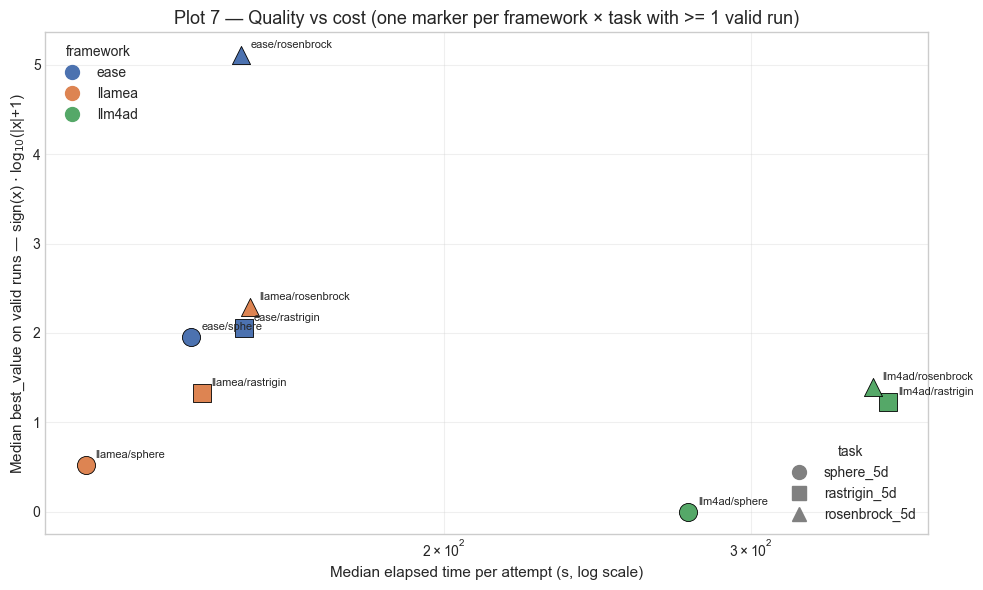

In [12]:
# Plot 7 — Quality vs cost scatter
fig, ax = plt.subplots(figsize=(10, 6))
markers = {"sphere_5d": "o", "rastrigin_5d": "s", "rosenbrock_5d": "^"}

for fw in FW_ORDER:
    for task in TASK_ORDER:
        sub = df[(df["framework"] == fw) & (df["task"] == task)]
        v   = sub[sub["harness_valid"]]["best_value"].to_numpy()
        if v.size == 0:
            continue
        med_t = float(np.nanmedian(sub["elapsed_sec"]))
        med_y = float(np.median(v))
        ax.scatter([med_t], [signed_log10(med_y)],
                   marker=markers[task], s=170,
                   color=FRAMEWORK_COLOR[fw], edgecolors="black", linewidths=0.6)
        ax.annotate(f"{fw}/{task.replace('_5d','')}", (med_t, signed_log10(med_y)),
                    textcoords="offset points", xytext=(7, 5), fontsize=8)

fw_handles = [plt.Line2D([], [], marker="o", linestyle="", color=FRAMEWORK_COLOR[fw],
                         markersize=10, label=fw) for fw in FW_ORDER]
task_handles = [plt.Line2D([], [], marker=markers[t], linestyle="", color="grey",
                           markersize=10, label=t) for t in TASK_ORDER]
leg1 = ax.legend(handles=fw_handles, title="framework", loc="upper left")
ax.add_artist(leg1)
ax.legend(handles=task_handles, title="task", loc="lower right")

ax.set_xscale("log")
ax.set_xlabel("Median elapsed time per attempt (s, log scale)")
ax.set_ylabel(r"Median best_value on valid runs — sign(x) $\cdot$ log$_{10}$(|x|+1)")
ax.set_title("Plot 7 — Quality vs cost (one marker per framework × task with >= 1 valid run)")
ax.grid(True, which="both", alpha=0.3)

omitted_fw = [fw for fw in FW_ORDER if int(df[df["framework"] == fw]["harness_valid"].sum()) == 0]
missing_cells = []
for fw in FW_ORDER:
    for task in TASK_ORDER:
        sub = df[(df["framework"] == fw) & (df["task"] == task)]
        n_att = len(sub)
        n_val = int(sub["harness_valid"].sum())
        if n_att and n_val == 0:
            missing_cells.append(f"{fw}×{task.replace('_5d', '')}: 0/{n_att} valid")
note_lines = []
if omitted_fw:
    note_lines.append("No harness-valid rows (any task): " + ", ".join(omitted_fw))
if missing_cells:
    note_lines.append("Cells with attempts but 0 valid objective:")
    note_lines.extend(f"  • {line}" for line in missing_cells)
if note_lines:
    ax.text(0.99, 0.02, "\n".join(note_lines),
            transform=ax.transAxes, ha="right", va="bottom", fontsize=8,
            bbox=dict(facecolor="white", alpha=0.92, edgecolor="grey"))
plt.tight_layout()
plt.show()

### Plot 8 — Performance profile (Dolan–Moré, adapted)

**What it shows.** For each task we record the **best** harness-valid `best_value` observed across all frameworks and seeds — call it `b*` for that task. For every harness-valid run we compute a shifted ratio `r = (best_value + ε) / (b* + ε)` (with `ε = 10⁻⁶` to handle near-zero best values). The plot shows, per framework and pooled across tasks, the **fraction of runs with `r ≤ τ`** as τ sweeps a log range from 1 upward.

**How to read it.** The curve that is **highest at τ = 1** wins outright most often. The curve that **rises fastest as τ grows** is the most robust — it lands close to the best with high probability. A flat low curve means most "valid" runs of that framework are still far from the best.

**Caveat.** Classical Dolan–Moré (Dolan & Moré, 2002) assumes the *same* problem instances across solvers. We have disjoint seeds, so we use task-wide best as the reference: the underlying problem (e.g. `sphere_5d`) is identical across seeds; only the RNG seed differs and the global optimum is the same. This is a reasonable adaptation, not a strict Dolan–Moré profile.

**Suggested caption.** *"Adapted Dolan–Moré performance profile (Dolan & Moré, 2002): for each framework, fraction of harness-valid runs whose best_value is within factor τ of the per-task best observed across all frameworks. Curves higher at τ = 1 win outright more often; faster-rising curves are more robust."*

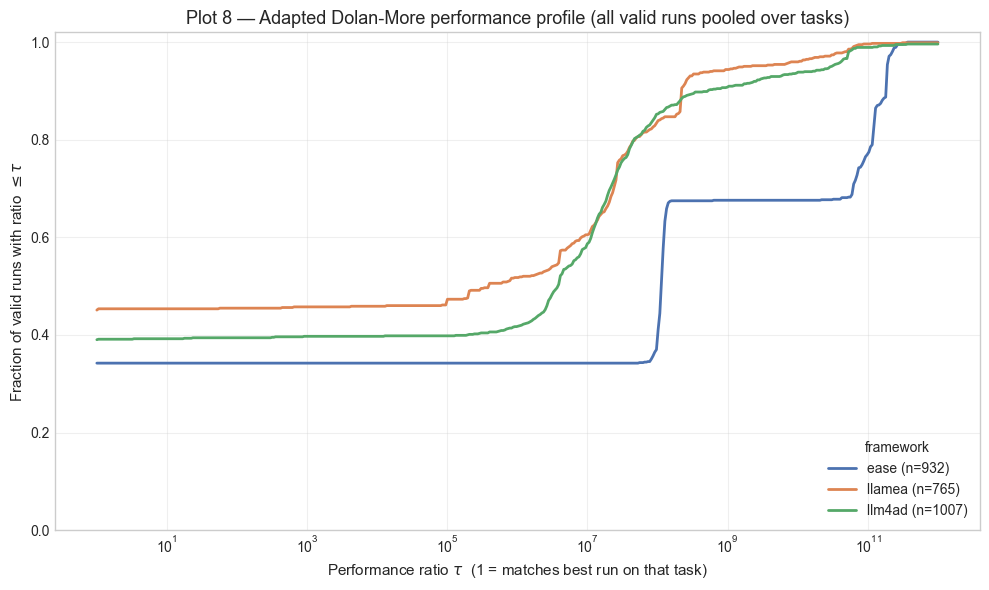

In [13]:
# Plot 8 — Adapted Dolan-More performance profile
EPS = 1e-6
ratios = {fw: [] for fw in FW_ORDER}

for task in TASK_ORDER:
    pool = valid[valid["task"] == task]["best_value"].to_numpy()
    if pool.size == 0:
        continue
    ref = float(np.min(pool))
    for fw in FW_ORDER:
        vals = valid[(valid["task"] == task) & (valid["framework"] == fw)]["best_value"].to_numpy()
        if vals.size == 0:
            continue
        r = (vals + EPS) / (ref + EPS)
        ratios[fw].extend(r.tolist())

fig, ax = plt.subplots(figsize=(10, 6))
tau_grid = np.logspace(0, 12, 500)
for fw in FW_ORDER:
    r = np.asarray(ratios[fw], dtype=float)
    if r.size == 0:
        ax.plot([], [], label=f"{fw} — no valid runs",
                color=FRAMEWORK_COLOR[fw], linewidth=2)
        continue
    pct = np.array([(r <= t).mean() for t in tau_grid])
    ax.plot(tau_grid, pct, label=f"{fw} (n={r.size})",
            color=FRAMEWORK_COLOR[fw], linewidth=2)

ax.set_xscale("log")
ax.set_xlabel(r"Performance ratio $\tau$  (1 = matches best run on that task)")
ax.set_ylabel(r"Fraction of valid runs with ratio $\leq \tau$")
ax.set_ylim(0, 1.02)
ax.set_title("Plot 8 — Adapted Dolan-More performance profile (all valid runs pooled over tasks)")
ax.legend(title="framework", loc="lower right")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

### Plot 9 — Stability over wall-clock time

**What it shows.** One panel per task. Every harness-valid run is a dot (x = wall-clock timestamp, y = `best_value` on signed-log scale). A solid line is the 30-run **rolling median** per framework. Frameworks with zero valid runs (e.g. EASE here) are absent from the panel.

**How to read it.** **Look at the rolling-median line.**
- A line that **slopes downward over time** means the framework is genuinely improving during the experiment — exactly what you'd hope to see from a *self-evolving* system.
- A **flat** line means the framework is at steady state — no learning, no degradation.
- A line that **slopes upward** means the framework is *regressing* — a serious red flag.
- A line that **drops then climbs** suggests overfitting / catastrophic re-evolution.

This is the most important plot in the notebook for evaluating the "self-evolving" claim, because the other plots show end-of-run quality without distinguishing whether that quality was earned by evolution or was already present in the seed code.

**Suggested caption.** *"Stability of best_value across the experiment: each dot is a harness-valid run plotted at its completion timestamp; solid lines are 30-run rolling medians per framework. A downward trend would indicate genuine self-evolution; flat means no in-experiment learning; upward indicates regression."*

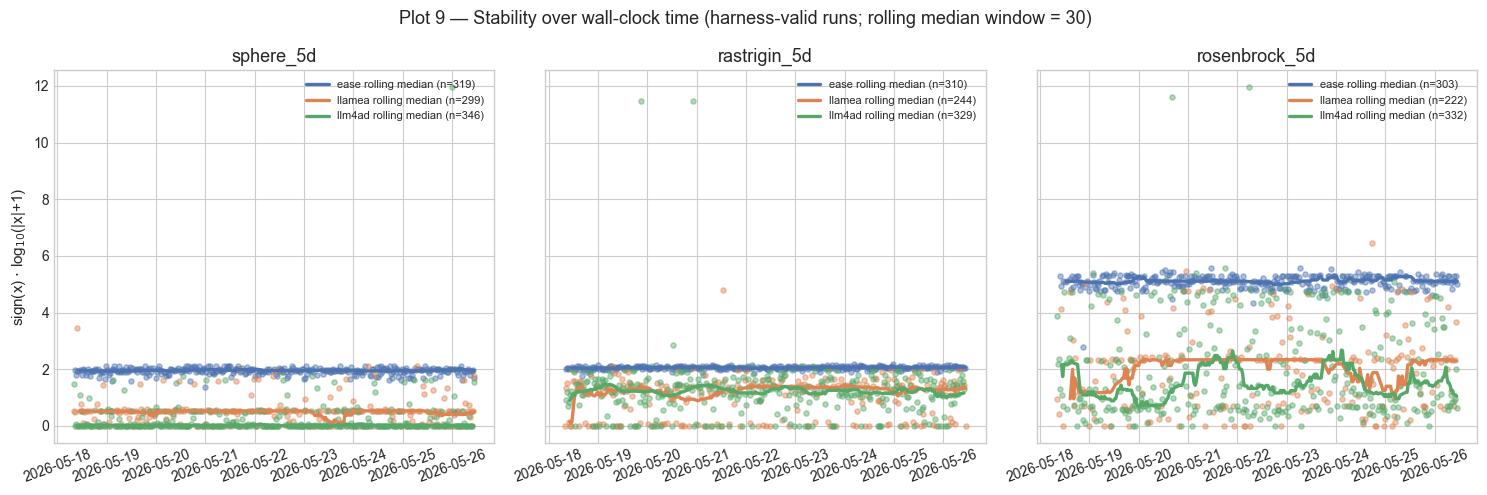

In [14]:
# Plot 9 — Stability over wall-clock time
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, task in zip(axes, TASK_ORDER):
    absent = []
    for fw in FW_ORDER:
        sub = (valid[(valid["task"] == task) & (valid["framework"] == fw)]
               .sort_values("timestamp"))
        if sub.empty:
            n_all = len(df[(df["task"] == task) & (df["framework"] == fw)])
            if n_all:
                absent.append(f"{fw} (0/{n_all} valid)")
            continue
        y = signed_log10(sub["best_value"].to_numpy())
        ax.scatter(sub["timestamp"], y, s=14, alpha=0.45,
                   color=FRAMEWORK_COLOR[fw])
        roll = pd.Series(y, index=sub["timestamp"]).rolling(30, min_periods=5).median()
        ax.plot(roll.index, roll.values, color=FRAMEWORK_COLOR[fw], linewidth=2.4,
                label=f"{fw} rolling median (n={len(sub)})")
    ax.set_title(task)
    ax.tick_params(axis="x", rotation=20)
    if task == TASK_ORDER[0]:
        ax.set_ylabel(r"sign(x) $\cdot$ log$_{10}$(|x|+1)")
    ax.legend(loc="upper right", fontsize=8)
    if absent:
        ax.text(0.02, 0.02, "Absent (no valid obj.):\n" + "\n".join(absent),
                transform=ax.transAxes, ha="left", va="bottom", fontsize=7, color="dimgray",
                bbox=dict(facecolor="white", alpha=0.85, edgecolor="lightgray"))
fig.suptitle("Plot 9 — Stability over wall-clock time (harness-valid runs; rolling median window = 30)",
             fontsize=13)
plt.tight_layout()
plt.show()

### Plot 10 — Pairwise `P(A beats B)` per task

**What it shows.** Three 3 × 3 heatmaps (one per task) where cell `(row=A, column=B)` is the probability that a **randomly chosen valid run from A has a *lower* best_value than a randomly chosen valid run from B**. This is `(1 + Cliff's δ) / 2`. Lower is better, so "A beats B" = "A's run is smaller". The diagonal is always 0.5. Cells with no valid runs are marked `NA`.

**How to read it.**
- A red cell (above 0.5) at `(A, B)` means **A wins more matchups than it loses** against B.
- A blue cell (below 0.5) at `(A, B)` means A loses more often.
- The two off-diagonal entries on each side of the diagonal are mirror images: `P(A beats B) + P(B beats A) ≈ 1` (with tiny slack for ties).

This is the *correct* "win-rate" to report when seed pools don't overlap — a head-to-head per-seed win-rate is mathematically undefined for this experiment, but the random-matchup probability is well-defined and is exactly what Cliff's δ encodes.

**Suggested caption.** *"Per-task pairwise probability that framework A produces a lower best_value than framework B on a random valid matchup, P(A beats B) = (1 + Cliff's δ) / 2. Cells with no valid runs are marked NA."*

C:\Users\ailab\AppData\Local\Temp\ipykernel_28944\99502784.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.93, 1])


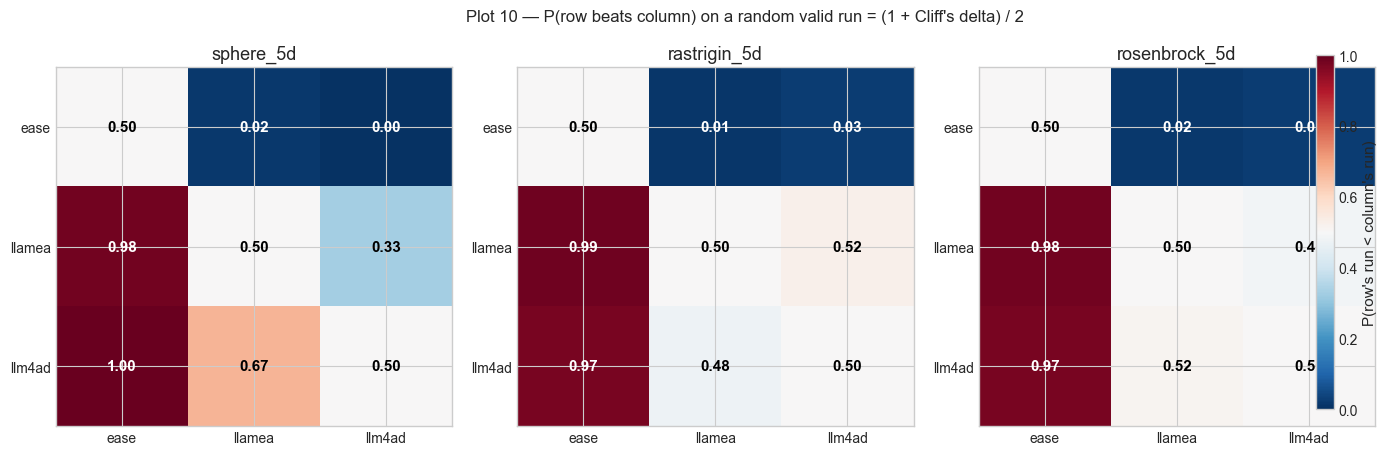

In [15]:
# Plot 10 — Per-task P(row beats column) heatmaps
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
im = None
for ax, task in zip(axes, TASK_ORDER):
    M = np.full((len(FW_ORDER), len(FW_ORDER)), np.nan)
    for i, a in enumerate(FW_ORDER):
        va = valid[(valid["task"] == task) & (valid["framework"] == a)]["best_value"].to_numpy()
        for j, b in enumerate(FW_ORDER):
            if i == j:
                M[i, j] = 0.5
                continue
            vb = valid[(valid["task"] == task) & (valid["framework"] == b)]["best_value"].to_numpy()
            if va.size == 0 or vb.size == 0:
                continue
            d, _ = cliffs_delta(va, vb)
            M[i, j] = (1 - d) / 2  # P(a < b) when lower is better

    im = ax.imshow(M, cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(FW_ORDER))); ax.set_xticklabels(FW_ORDER)
    ax.set_yticks(range(len(FW_ORDER))); ax.set_yticklabels(FW_ORDER)
    ax.set_title(task)
    for i in range(len(FW_ORDER)):
        for j in range(len(FW_ORDER)):
            v = M[i, j]
            label = "NA" if not np.isfinite(v) else f"{v:.2f}"
            txt_color = "black" if (not np.isfinite(v) or 0.25 <= v <= 0.75) else "white"
            ax.text(j, i, label, ha="center", va="center",
                    fontsize=11, color=txt_color, fontweight="bold")

fig.suptitle("Plot 10 — P(row beats column) on a random valid run = (1 + Cliff's delta) / 2",
             fontsize=12)
if im is not None:
    cbar = fig.colorbar(im, ax=axes.tolist(), fraction=0.025, pad=0.04)
    cbar.set_label("P(row's run < column's run)")
plt.tight_layout(rect=[0, 0, 0.93, 1])
plt.show()

In [16]:
from IPython.display import Markdown

# Reliability ranking (overall)
overall_rel = (cov.groupby("framework", observed=True)
                 .apply(lambda g: g["n_harness_valid"].sum() / g["n_attempts"].sum())
                 .sort_values(ascending=False))

# Per-task winner on objective median (harness-valid only)
best_by_task = (desc.sort_values(["task", "median"])
                    .groupby("task", observed=True).first().reset_index()
                    [["task", "framework", "median", "n", "median_ci_lo", "median_ci_hi"]])

# Per-task most reliable
rel_by_task = (cov.sort_values(["task", "rate"], ascending=[True, False])
                  .groupby("task", observed=True).first().reset_index()
                  [["task", "framework", "rate", "ci_lo", "ci_hi", "n_attempts"]])


def significance_for_winner(task: str, winner: str) -> list[dict]:
    sub = pairs[(pairs["task"] == task) & ((pairs["A"] == winner) | (pairs["B"] == winner))]
    out = []
    for _, r in sub.iterrows():
        if not np.isfinite(r["cliffs_delta"]):
            continue
        other = r["B"] if r["A"] == winner else r["A"]
        sign = -1 if r["A"] == winner else 1
        # delta < 0 means A < B; if A is the winner, signed delta = -delta is positive when winner is better
        d_for_winner = sign * r["cliffs_delta"]
        out.append({"loser": other, "p_holm": r["p_holm"],
                    "delta_for_winner": d_for_winner, "magnitude": r["magnitude"]})
    return out


lines: list[str] = []
lines.append("## Executive summary (computed from data above — no hand-written claims)")
lines.append("")
lines.append(f"- **Dataset**: {len(df)} runs total, balanced ({len(FW_ORDER)} frameworks x {len(TASK_ORDER)} tasks x {TARGET_N} attempts/cell).")
lines.append(f"- **Time range**: {df['timestamp'].min():%Y-%m-%d} to {df['timestamp'].max():%Y-%m-%d}.")
lines.append("- **Seed overlap across frameworks**: 0 on every task. All cross-framework comparisons are unpaired.")
lines.append("")
lines.append("### Reliability (harness-valid rate = success AND objective passes bound check)")
lines.append("")
lines.append("| framework | overall rate |")
lines.append("|---|---|")
for fw, r in overall_rel.items():
    lines.append(f"| `{fw}` | {r*100:.1f}% |")
lines.append("")
lines.append("Per-task most reliable framework:")
for _, r in rel_by_task.iterrows():
    lines.append(f"- **{r['task']}** → `{r['framework']}` at {r['rate']*100:.1f}% "
                 f"(95% CI {r['ci_lo']*100:.1f}–{r['ci_hi']*100:.1f}, n={int(r['n_attempts'])}).")
lines.append("")
lines.append("### Objective quality — lowest median, harness-valid runs only")
lines.append("")
for _, w in best_by_task.iterrows():
    sigs = significance_for_winner(w["task"], w["framework"])
    bits = []
    for s in sigs:
        sense = "better than" if s["delta_for_winner"] > 0 else "worse than"
        marker = "significantly " if s["p_holm"] < 0.05 else "not significantly "
        bits.append(f"{marker}{sense} `{s['loser']}` "
                    f"(Cliff's δ = {s['delta_for_winner']:+.2f} [{s['magnitude']}], "
                    f"p_holm = {fmt_p(s['p_holm'])})")
    bits_text = "; ".join(bits) if bits else "—"
    lines.append(f"- **{w['task']}** → lowest median: `{w['framework']}` at {w['median']:.4g} "
                 f"(95% CI {w['median_ci_lo']:.4g}–{w['median_ci_hi']:.4g}, n={int(w['n'])}). "
                 f"It is {bits_text}.")
lines.append("")
lines.append("### Compute cost")
lines.append("")
for fw in FW_ORDER:
    med = float(runtime_overall.loc[fw, "median"])
    p90 = float(runtime_overall.loc[fw, "p90"])
    lines.append(f"- `{fw}`: median {med:.0f}s / p90 {p90:.0f}s per run.")
lines.append("")

# Honesty section — auto-flag any framework whose face-value scores are mostly invalid
warnings: list[str] = []
for fw in FW_ORDER:
    r = df[df["framework"] == fw]["harness_valid"].mean()
    if r < 0.85:
        warnings.append(f"- `{fw}` is at only **{r*100:.1f}%** harness-valid — interpret its "
                        f"raw objective values with caution.")
for fw in FW_ORDER:
    n_negbug = int(((df["framework"] == fw) & df["success"] & (df["best_value"] < -1e-3)).sum())
    if n_negbug > 0:
        warnings.append(f"- `{fw}` reported **{n_negbug}** 'successful' runs with negative "
                        f"`best_value` on non-negative objectives. These are excluded from the "
                        f"quality comparison; including them would let a metric-hacking bug win.")
if warnings:
    lines.append("### Caveats automatically flagged")
    lines.append("")
    lines.extend(warnings)

Markdown("\n".join(lines))

## Executive summary (computed from data above — no hand-written claims)

- **Dataset**: 3240 runs total, balanced (3 frameworks x 3 tasks x 360 attempts/cell).
- **Time range**: 2026-05-18 to 2026-05-26.
- **Seed overlap across frameworks**: 0 on every task. All cross-framework comparisons are unpaired.

### Reliability (harness-valid rate = success AND objective passes bound check)

| framework | overall rate |
|---|---|
| `llm4ad` | 93.2% |
| `ease` | 86.3% |
| `llamea` | 70.8% |

Per-task most reliable framework:
- **sphere_5d** → `llm4ad` at 96.1% (95% CI 93.6–97.7, n=360).
- **rastrigin_5d** → `llm4ad` at 91.4% (95% CI 88.0–93.9, n=360).
- **rosenbrock_5d** → `llm4ad` at 92.2% (95% CI 89.0–94.6, n=360).

### Objective quality — lowest median, harness-valid runs only

- **sphere_5d** → lowest median: `llm4ad` at 0.002088 (95% CI 0.0008735–0.02745, n=346). It is significantly better than `ease` (Cliff's δ = +0.99 [large], p_holm = 1.5e-107); significantly better than `llamea` (Cliff's δ = +0.34 [medium], p_holm = 3.0e-13).
- **rastrigin_5d** → lowest median: `llm4ad` at 15.94 (95% CI 13.57–18.49, n=329). It is significantly better than `ease` (Cliff's δ = +0.95 [large], p_holm = 7.3e-95); not significantly worse than `llamea` (Cliff's δ = -0.05 [negligible], p_holm = 0.6637).
- **rosenbrock_5d** → lowest median: `llm4ad` at 23.59 (95% CI 14.2–40.59, n=332). It is significantly better than `ease` (Cliff's δ = +0.95 [large], p_holm = 3.8e-94); not significantly better than `llamea` (Cliff's δ = +0.03 [negligible], p_holm = 0.6637).

### Compute cost

- `ease`: median 150s / p90 189s per run.
- `llamea`: median 140s / p90 200s per run.
- `llm4ad`: median 333s / p90 451s per run.

### Caveats automatically flagged

- `llamea` is at only **70.8%** harness-valid — interpret its raw objective values with caution.
- `llm4ad` reported **8** 'successful' runs with negative `best_value` on non-negative objectives. These are excluded from the quality comparison; including them would let a metric-hacking bug win.

## Methodological notes & threats to validity

- **Why median + bootstrap CI instead of mean ± std?** The distributions are heavy-tailed (`llm4ad` reaches ~9 × 10¹¹ on rastrigin, `llamea` reaches ~3.6 × 10⁵ on rosenbrock). The mean is dominated by a handful of catastrophic runs and is not a stable estimate of central tendency; the median is.
- **Why Mann–Whitney U + Cliff's δ?** The seed pools are disjoint across frameworks, so paired tests (Wilcoxon signed-rank) are not applicable. The distributions are clearly non-normal and bounded below by 0, so unpaired rank-based tests with a non-parametric effect size are the right tool. Cliff's δ answers the practitioner's actual question — *"if I take one random run from A and one from B, how often does A win?"*.
- **Why filter through `is_valid_reported_objective`?** Sphere, Rastrigin and Rosenbrock have global minimum `0`. Any negative reported `best_value` is either a numerical exploit or a reporting bug — never a real optimum. Including them lets the buggiest framework win the benchmark trivially, which is exactly what made the original plots misleading.
- **Why Newcombe + Fisher for reliability?** Wilson on each rate alone gives per-cell coverage; Newcombe's method gives a calibrated CI on the *difference of two rates* (which is what the comparison is actually about). Fisher's exact handles the small-cell scenarios that an asymptotic chi-square would mishandle.
- **What we did NOT analyse.** Convergence trajectories (per-iteration objective curves are not in this per_run dataset), token / LLM-call cost (also not stored here), and seed-aligned variance (impossible — disjoint seeds). For convergence and tokens, run the analysis against the `*.jsonl` log files via `analyze_benchmark.py` and we can extend this notebook.
- **Reproducibility.** Bootstrap uses a fixed seed (`np.random.default_rng(42)`). Mann–Whitney and Fisher are deterministic. Holm correction is deterministic. Rerunning the notebook produces bit-identical tables.